In [1]:
import matplotlib.pyplot as plt
from matplotlib.colors import PowerNorm
import pandas as pd
import seaborn as sns
import torch
import numpy as np
import scipy

from pi_solvers import sde_lib, solver_lib, gaussian_score_testing
from pi_solvers.utils import data_logger

torch.manual_seed(42)

In [2]:
# SDE Setup
beta_min = 0.1
beta_max = 20
sde = sde_lib.LinearVariancePreservingSDE(beta_min, beta_max)

In [3]:
# Gaussian & score setup

multi_gaussian = gaussian_score_testing.complex_gaussian(sde)
score_func = multi_gaussian.get_score_function()

# Create reverse sde_lib based on score function
reverse_sde = sde.get_reverse_sde(score_func)

Text(0.5, 0, 'x')

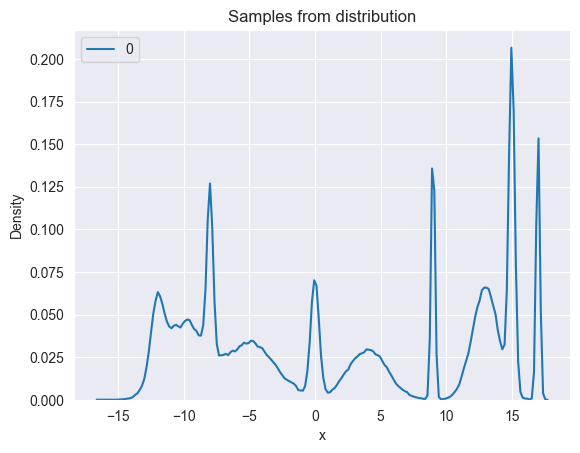

In [4]:
# Sampling
n_samples = 100000
samples = multi_gaussian.sample(n_samples).unsqueeze(-1)
x_ground_truth = torch.sort(samples)[0]

plt.figure()
sns.kdeplot(x_ground_truth, bw_adjust=0.1)
plt.title("Samples from distribution")
plt.xlabel("x")

Text(0.5, 0, 'x')

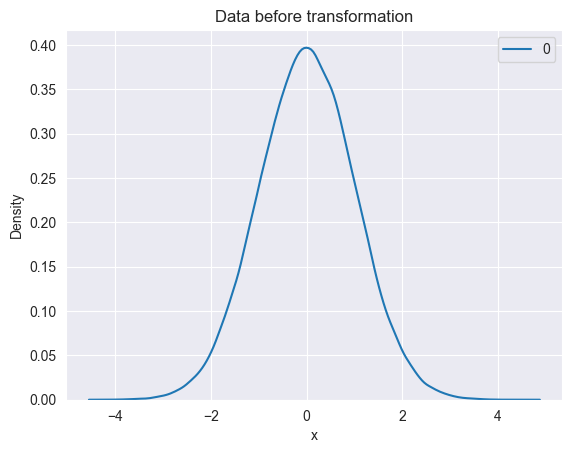

In [5]:
# Sample x from the marginal
x_start = sde.sample(x_ground_truth, torch.Tensor([1]))

# Plot initial data
plt.figure()
sns.kdeplot(x_start)
plt.title("Data before transformation")
plt.xlabel("x")

In [6]:
# Euler Marayuma setup
multi_gaussian.reset_nfe()

x_em_log = []
t_em_log = []

def log_em(x: torch.Tensor, t: torch.Tensor):
    # Track 4 x from the batch
    x_em_log.append(x[0:4, :].clone())
    t_em_log.append(t.clone())

n_steps = 50
discretisation = torch.linspace(1, 0, n_steps + 1)
em_solver = solver_lib.EulerMarayumaSolver(reverse_sde, discretisation)

x_em = em_solver.solve(x_start.clone(), callback=log_em)

# Logging
x_em_log = np.array(x_em_log)[:, :, 0]
t_em_log = np.array(t_em_log)

# Baseline PDF
interval = torch.linspace(torch.min(x_em) - 3, torch.max(x_em) + 3, 10000).unsqueeze(-1)
verification = multi_gaussian(interval)

Text(0.5, 0, 'x')

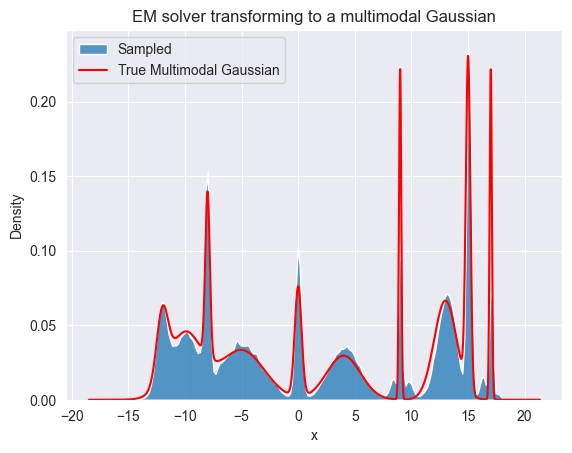

In [7]:
# Euler Marayuma Plots
plt.figure()
sns.kdeplot(x_em, label="Sampled", multiple="stack", bw_adjust=0.1)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("EM solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [8]:
# Euler Marayuma Evaluation
nfe_em_per_sample = multi_gaussian.nfe / n_samples
wasserstein_distance_em = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_em)[0][:, 0])

print(f"NFE per sample for Euler-Marayuma sampler: {nfe_em_per_sample}")
print(f"Wasserstein distance for Euler-Marayuma sampler: {wasserstein_distance_em}")

NFE per sample for Euler-Marayuma sampler: 50.0
Wasserstein distance for Euler-Marayuma sampler: 0.28917290435451254


In [13]:
# PI solver setup
reverse_sde.reset()
torch.manual_seed(42)

x_pi_log = [torch.zeros(4, 1)]
t_pi_log = [torch.ones(4, 1)]
t_log = []
h_log = []

def log_pi(x: torch.Tensor, t: torch.Tensor, h: torch.tensor, error, **kwargs):
    # Track 4 x from the batch
    x_pi_log.append(x[0:4, :].clone())
    t_pi_log.append(t[0:4, :].clone())
    t_log.append(t.clone())
    h_log.append(h.clone())


pi_solver = solver_lib.PISolver(
    reverse_sde,
    ki=0.3, 
    kp=0.1, 
    tau_a=0.15, 
    tau_r=0,
    alpha=0.9,
    h_start=0.15,
    max_decrease=0.2,
    max_increase=5,
    seed=0
)

logger = data_logger.PIDataLogger(write_path="../data/gaussian_test/complex_4/", batch_size=100000)

x_pi = pi_solver.solve(x_start.clone(), callback=logger)
logger.write()

# Logging
x_pi_log = np.array(x_pi_log)[:, :, 0]
t_pi_log = np.array(t_pi_log)[:, :, 0]

# Baseline PDF
interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 10000).reshape((10000, 1))
verification = multi_gaussian(interval)

Text(0.5, 0, 'x')

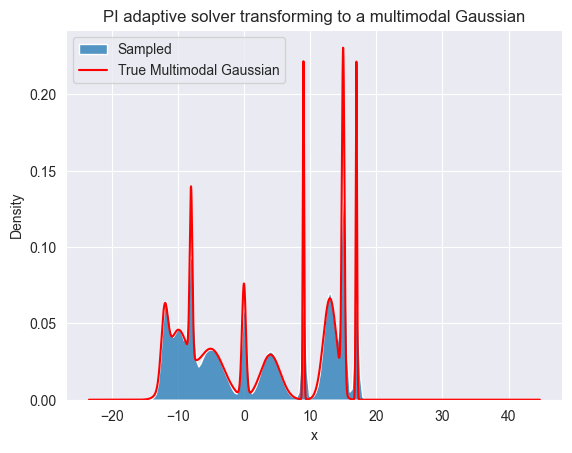

In [14]:
# PI Plots
plt.figure()
sns.kdeplot(x_pi, label="Sampled", multiple="stack", bw_adjust=0.3)
plt.plot(interval, verification, c="r", label="True Multimodal Gaussian")
plt.legend()
plt.title("PI adaptive solver transforming to a multimodal Gaussian")
plt.xlabel("x")

In [15]:
# PI Evaluation
nfe_pi_per_sample = reverse_sde.nfe / x_start.shape[0]
wasserstein_distance_pi = scipy.stats.wasserstein_distance(x_ground_truth[:, 0], torch.sort(x_pi)[0][:, 0])

print(f"NFE per sample for PI sampler: {nfe_pi_per_sample}")
print(f"Wasserstein distance for PI sampler: {wasserstein_distance_pi}")

NFE per sample for PI sampler: 54.56434
Wasserstein distance for PI sampler: 0.1259415877608271


In [18]:
df = pd.read_csv("gaussian_results/data-1775071551.0/data.csv")

plt.figure()
sns.scatterplot(df, x="em_nfe", y="em_error", label="Euler Marayuma Solver")
sns.scatterplot(df, x="pi_nfe", y="pi_error", label="Proportional Integral Solver")
plt.xlabel("NFE")
plt.xlim(0, 500)
plt.ylim(0, 2)
plt.ylabel("Error")
plt.title("NFE - Error trade off")
plt.legend()

FileNotFoundError: [Errno 2] No such file or directory: 'gaussian_results/data-1775071551.0/data.csv'

In [12]:
# Create probability density colour map
x_interval = torch.linspace(torch.min(x_pi) - 3, torch.max(x_pi) + 3, 300)
t_interval = torch.linspace(0, 1, 200)
X, T = torch.meshgrid(x_interval, t_interval)
C = torch.zeros(X.shape)

for i, t in enumerate(t_interval):
    C[:, i] = multi_gaussian.multigaussian_at_t(t)(x_interval)

C:\Users\ellak\PycharmProjects\proportial-integral-generative-sde-solvers\Lib\site-packages\torch\functional.py:505: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\TensorShape.cpp:4383.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


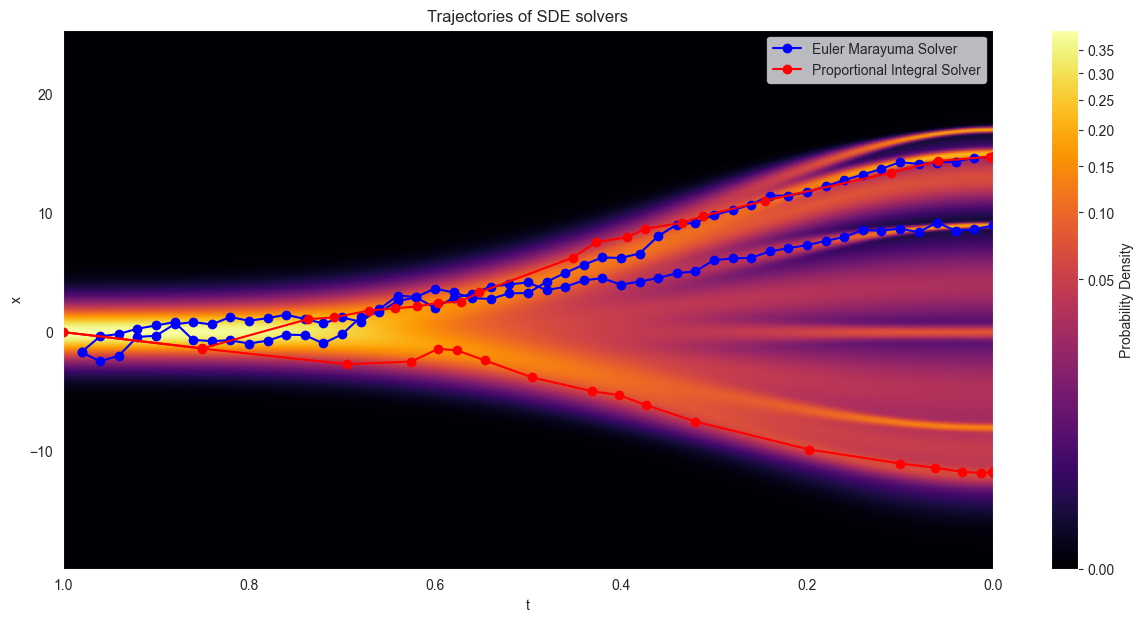

In [55]:
# Plotting
plt.figure(figsize=(15, 7))
plt.title("Trajectories of SDE solvers")

plt.xlim(1, 0)
mesh = plt.pcolormesh(T, X, C, cmap='inferno', shading='gouraud', norm=PowerNorm(gamma=0.3))
plt.colorbar(mesh,label='Probability Density')
for i in range(2):
    em = plt.plot(t_em_log[:, i, 0], x_em_log[:, i], 'bo-')
em[0].set_label("Euler Marayuma Solver")

for i in range(2):
    pi = plt.plot(t_pi_log[:, i], x_pi_log[:, i], 'ro-')
pi[0].set_label("Proportional Integral Solver")

plt.xlabel("t")
plt.ylabel("x")
plt.legend()
    
plt.show()

In [45]:
ts = torch.concat(t_log)
hs = torch.concat(h_log)
ts = ts[ts > 0]
hs = hs[hs < 0]

In [46]:
ts.shape, hs.shape

(torch.Size([2380553]), torch.Size([2380553]))

C:\Users\ellak\AppData\Local\Temp\ipykernel_22616\190429578.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


Text(0, 0.5, 'time-step')

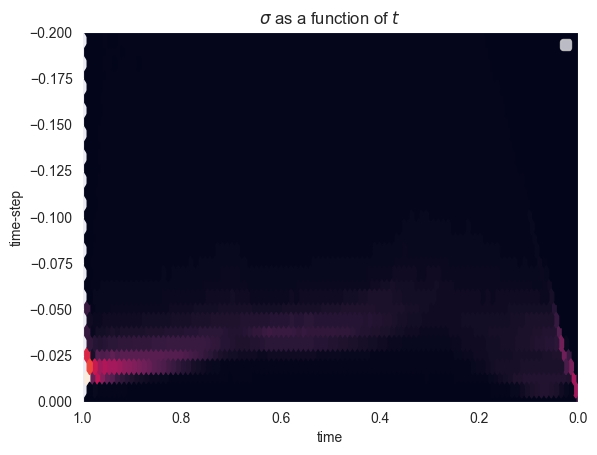

In [56]:
plt.title(r"$\sigma$ as a function of $t$")

plt.hexbin(x=ts, y=hs, bins=100)

plt.legend()
plt.xlim(1, 0)
plt.ylim(0, -0.2)
plt.xlabel("time")
plt.ylabel("time-step")